In [353]:
import heapq
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import matplotlib.colors as mcolors
import cv2.aruco as aruco
import math

In [355]:
# start=(20, 20)  # Starting position# start = (420, 385)#(20, 20)  # Starting position
# goal=(400, 385)   # Goal position# goal = (20,20)#(400, 385)   # Goal position
start = (90, 366)  # Starting position
goal = (360, 110)  # Goal position
maze_height=390
maze_width=450

In [357]:
######      transform and converts a maze image to a matrix 
def transform_and_convert_image_to_matrix(image_path, transforming=True,
                                          transformed_file_name='maze_robot',
                                          maze_height=maze_height, maze_width=maze_width):

    image = cv.imread(image_path)   # Read image
    transformed_image_filename = f"transformed-{transformed_file_name}.png"

    if transforming :
        # make ArUco dictionary and detection parameters
        aruco_dict = aruco.getPredefinedDictionary(aruco.DICT_4X4_50)
        parameters = aruco.DetectorParameters()
        corners, ids, rejected = aruco.detectMarkers(image, aruco_dict, parameters=parameters) # Detect markers in the image
    
        if ids is not None and len(ids) == 4: # check marker are detcted or not, if yes:
        
            src_points = np.zeros((4, 2), dtype=np.float32) # map IDs to the corresponding center points
            scale_factor = 1  # Adjust this scale if you want to change the output resolution
            width = int(maze_width * scale_factor)
            height = int(maze_height * scale_factor)
            destionation_points = np.array([[0, 0], [width, 0], [width, height], [0, height]], dtype=np.float32)
            
            
            
            for i, marker_id in enumerate(ids.flatten()): # calculate the center of each marker for each marker
                c0, c1, c2, c3 = corners[i][0]  # Get the four corner points of the marker
                center_x = (c0[0] + c1[0] + c2[0] + c3[0]) / 4
                center_y = (c0[1] + c1[1] + c2[1] + c3[1]) / 4
                
                # assign to src_points based on the marker ID
                # marker sequation is bottom left , top left, top right, bottom right (out put of detected marker started form top left)
                if marker_id == 0:  # Bottom Left
                    src_points[3] = [center_x, center_y]
                elif marker_id == 1:  # Top Left
                    src_points[0] = [center_x, center_y]
                elif marker_id == 2:  # Top Right
                    src_points[1] = [center_x, center_y]
                elif marker_id == 3:  # Bottom Right
                    src_points[2] = [center_x, center_y]
    
            perspective_matrix = cv.getPerspectiveTransform(src_points, destionation_points) # compute perspective transformation matrix
            transformed_image = cv.warpPerspective(image, perspective_matrix, (width, height))  # apply it
            cv.imwrite(transformed_image_filename, transformed_image) #save_transformed image
        
        else:
            print("No marker detected")
    else:
        transformed_image = image
    
    
    grayscale_image = cv.cvtColor(transformed_image, cv.COLOR_BGR2GRAY) # Convert image to grayscale
    blurred_image = cv.GaussianBlur(grayscale_image,(3,3),0)  # Apply Gaussian blur to reduce noise
    resized_image = cv.resize(blurred_image,(maze_width, maze_height))  # Resize image with our desigre height and with
    edges_detected = cv.Canny(image=resized_image, threshold1=45, threshold2=200, apertureSize=3)  # Edge detection by Canny
    
    blurred_image= cv.GaussianBlur(edges_detected, (5,5),0)
    blurred_image[blurred_image > 50] = 255
    edged_detected = cv.Canny(image=blurred_image, threshold1=45, threshold2=200, apertureSize=3)
    
    edges_detected[edges_detected > 0] = 1  # Convert edge pixels  morethen 0 to 1
    
    return np.array(np.flip(edges_detected, axis=0))  # Return the matrix ( make it based on cartesian)


In [359]:
#function to show matrix (invert in y axis , because we want to see everything based on cartesion)
def imshow_maze_matrix(maze):
    plt.imshow(maze)
    plt.gca().invert_yaxis()

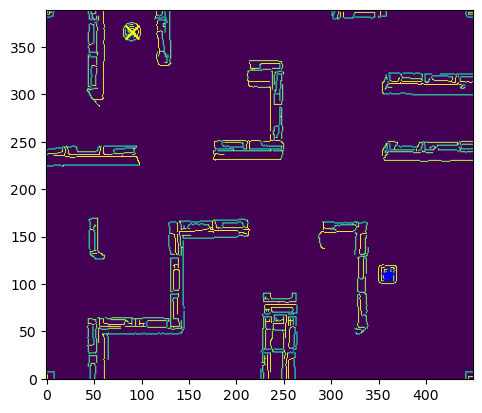

In [361]:
#example:
# maze_matrix = convert_image_to_matrix('transformed_image.jpg')
maze_matrix = transform_and_convert_image_to_matrix('robot_game_with_se.jpg', transforming=True,
                                                    transformed_file_name='robot_game_with_se',
                                                    maze_height=maze_height, maze_width=maze_width)
imshow_maze_matrix(maze_matrix)
plt.scatter([start[0]], [start[1]], color="yellow", s=100, marker='x')
plt.scatter([goal[0]], [goal[1]], color="blue", s=100, marker='*')
#plt.show()

In [363]:
image2 = cv.imread('transformed-robot_game.png')
# image_robot = cv.imread('image132.jpg')
# image_robot2 = cv.imread('image_robot_after_transform.png')
selected_point = cv.imread('end_point.png')
# selected_point = cv.imread('end_point.png')

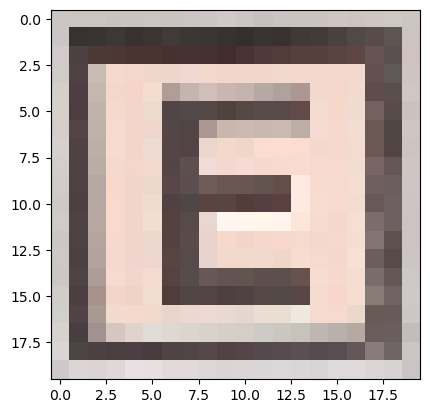

In [365]:
plt.imshow(selected_point)

In [367]:


# Load the main image and the template image
main_image = image2
template = selected_point

# Convert both images to grayscale
main_gray = cv.cvtColor(main_image, cv.COLOR_BGR2GRAY)
template_gray = cv.cvtColor(template, cv.COLOR_BGR2GRAY)

# Get the width and height of the template image
template_height, template_width = template_gray.shape

# Perform template matching
result = cv.matchTemplate(main_gray, template_gray, cv.TM_CCOEFF_NORMED)

# Find the coordinates of the best match
min_val, max_val, min_loc, max_loc = cv.minMaxLoc(result)

# The top-left corner of the template in the main image
top_left = max_loc
bottom_right = (top_left[0] + template_width, top_left[1] + template_height)

# Calculate the center position of the matched region
center_x = top_left[0] + template_width // 2
center_y = top_left[1] + template_height // 2
center_position = (center_x, center_y)

# Draw a rectangle and a circle at the center
cv.rectangle(main_image, top_left, bottom_right, (0, 255, 0), 2)
cv.circle(main_image, center_position, 5, (255, 0, 0), -1)

# Display the result
cv.imshow("Matched Image", main_image)
# cv.waitKey(0)
# cv.destroyAllWindows()

# Print the center position
print("Center position of the object:", center_position)

Center position of the object: (360, 280)


In [369]:
center_position

(360, 280)

In [371]:
x=390-center_position[1]

In [373]:
x

110

In [375]:
point=(center_position[0],x)

In [377]:
point

(360, 110)

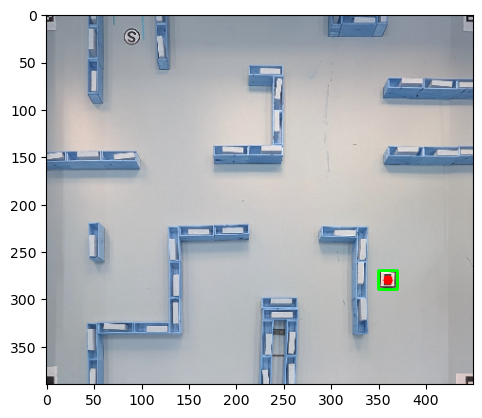

In [379]:
plt.imshow(main_image)

In [250]:
y=370%360

In [252]:
y

10